In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,test_energy_consistency,optimize_energy, compute_error, compute_energy

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pandas as pd

sys.path.append("pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Exakte Energie       :  -7.819890870294844
Startparameter       : [-3.14159265 -1.57079633  1.57079633]
Optimierte Parameter : [-3.14159265 -1.5707083   1.57074887]
Minimaler Fehler     : 0.10484684938626694


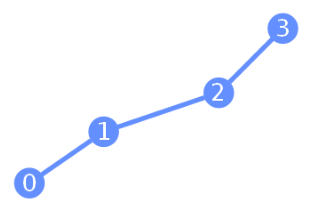

In [2]:
# Lineare Kopplung: 0–1–2–3
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3), (1,0), (2,1), (3,2)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

plot_gate_map(backend)

hx = 1
hz = 1
J=-1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

print("Exakte Energie       : ", energy_exact)
print("Startparameter       :",best_guess)
print("Optimierte Parameter :", opt_params)
print("Minimaler Fehler     :", min_error)

In [3]:
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)
pauli_list = paulis
print(pauli_list)

['IIZZ', 'IZZI', 'ZZII', 'IIIX', 'IIIZ', 'IIXI', 'IIZI', 'IXII', 'IZII', 'XIII', 'ZIII']


In [4]:
df = pd.DataFrame({
    'Pauli': paulis,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIZZ,1.000000
1,IZZI,1.000000
2,ZZII,1.000000
3,IIIX,-0.000088
4,IIIZ,-1.000000
5,IIXI,0.000088
6,IIZI,-1.000000
7,IXII,0.000088
8,IZII,-1.000000
9,XIII,-0.000088


In [5]:
inst_map = [0,1,2,3]
qc = build_hva_layers(opt_params, backend, num_layers=1)

qc.draw(fold=-1)

┌───┐┌─────────────┐┌────────────┐                                        
q_0: ┤ H ├┤ Rz(-1.5707) ├┤ Rx(1.5707) ├──■──────────────■──────────────────────
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────┐┌─┴─┐                    
q_1: ┤ H ├┤ Rz(-1.5707) ├┤ Rx(1.5707) ├┤ X ├┤ Rz(-π) ├┤ X ├──■──────────────■──
     ├───┤├─────────────┤├────────────┤└───┘└────────┘└───┘┌─┴─┐┌────────┐┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.5707) ├┤ Rx(1.5707) ├──■──────────────■──┤ X ├┤ Rz(-π) ├┤ X ├
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌────────┐┌─┴─┐└───┘└────────┘└───┘
q_3: ┤ H ├┤ Rz(-1.5707) ├┤ Rx(1.5707) ├┤ X ├┤ Rz(-π) ├┤ X ├────────────────────
     └───┘└─────────────┘└────────────┘└───┘└────────┘└───┘

In [6]:
# --- 5. Simulator instanziieren ---
backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator(noise_model=noise_model)

In [7]:
from src.calculate_runs import count_tomography_runs_from_repo, count_per_runs

# TOMOGRAPHY
res_tomo = count_tomography_runs_from_repo(
    qc=qc,
    inst_map=inst_map,
    backend=backend,
    used_qubits=inst_map,
    depths=[2,4,16,32,64],
    samples=100,
    single_samples=250,
    shots=1024   # optional
)
print("Tomography: ",res_tomo['backend_runs'])

# PER
res_per = count_per_runs(
    qc=qc,
    pauli_list=pauli_list,
    noise_strengths=[0,1,2],
    samples=1000,
    shots=1024   # optional
)
print("PER: ",res_per['backend_runs'])
print("Total: ",res_per['backend_runs'] + res_tomo['backend_runs'])

Tomography:  12288000
PER:  6144000
Total:  18432000


Sparse Pauli Tomography

$$ N_{\mathrm{tomo}} = N_{\mathrm{layers}} \cdot ( 9 \cdot |D| \cdot S ) + \sum_{\ell=1}^{N_{\mathrm{layers}}} ( \, |\text{single\_bases}(\ell)| \cdot S_{\mathrm{single}} )$$
	
$N_{\mathrm{layers}}$ = Anzahl der Clifford-Layer im Circuit

9  = feste Zahl der Messbasen

|D| = Anzahl der Tiefenwerte (z.\,B. [2,4,16,32,64])

S  = Samples (Twirls pro Basis+Tiefe)

|single\_bases($\ell$)| = Zahl der Single-Bases für Layer $\ell$

$S_{\mathrm{single}}$ = Samples für die Single-Bases

----------------------------------------------------------------------

PER
	$$
	N_{\mathrm{PER}}
	= N_{\mathrm{input}} \cdot N_{\mathrm{meas\_bases}}^{\mathrm{PER}} \cdot |N_{\mathrm{strengths}}| \cdot S
	$$
	
$N_{\mathrm{input}}$ = Anzahl der Eingabecircuits 

$N_{\mathrm{meas\_bases}}^{\mathrm{PER}}$ = minimale Zahl Messbasen, die pauli\_list abdeckt

$|N_{\mathrm{strengths}}|$= Anzahl der verschiedenen Noise-Stärken

$S$= Samples (Twirls pro Basis)

In [8]:
# Tomography Ergebnisse
print("=== Tomography ===")
print("Circuits:      ", res_tomo["circuits"])
if "backend_runs" in res_tomo:
    print("Backend runs: ", res_tomo["backend_runs"])

print("Details:")
print("  N_layers        :", res_tomo["details"]["num_layers"])
print("  num_meas_bases  :", res_tomo["details"]["num_meas_bases"])
print("  depth_count     :", res_tomo["details"]["depth_count"])
print("  samples         :", res_tomo["details"]["samples"])
print("  single_samples  :", res_tomo["details"]["single_samples"])
print("  sum_single_bases:", res_tomo["details"]["sum_single_bases"])


# PER Ergebnisse
print("\n=== PER ===")
print("Circuits:      ", res_per["circuits"])
if "backend_runs" in res_per:
    print("Backend runs: ", res_per["backend_runs"])

print("Details:")
print("  num_meas_bases_per :", res_per["details"]["num_meas_bases_per"])
print("  num_noise_strengths:", res_per["details"]["num_noise_strengths"])
print("  samples            :", res_per["details"]["samples"])


=== Tomography ===
Circuits:       12000
Backend runs:  12288000
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 5
  samples         : 100
  single_samples  : 250
  sum_single_bases: 12

=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000


In [9]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

In [10]:
#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

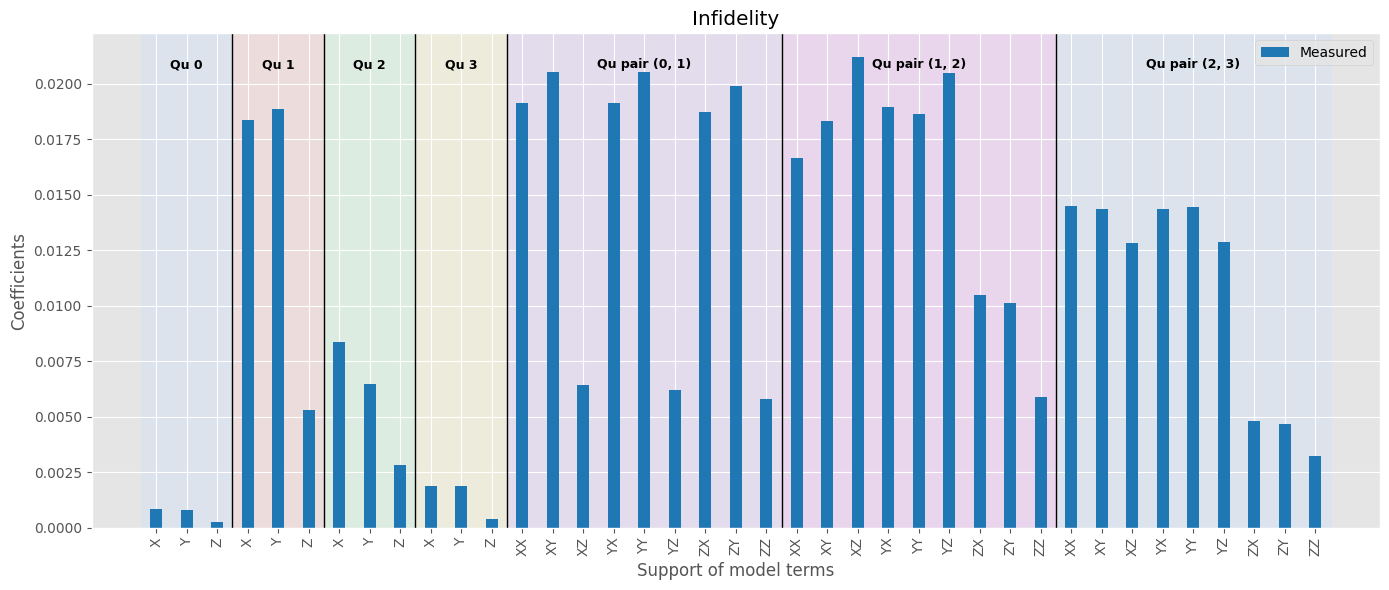

In [11]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

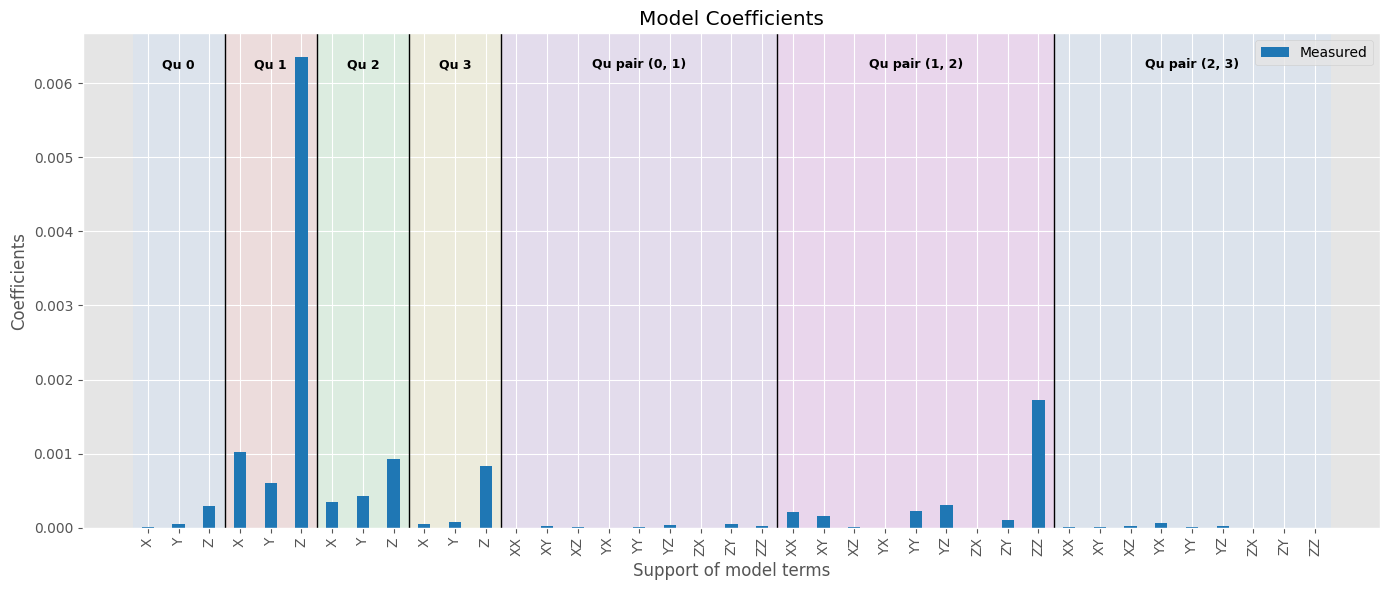

In [12]:
layer1.plot_coeffs(plot_style = 2)

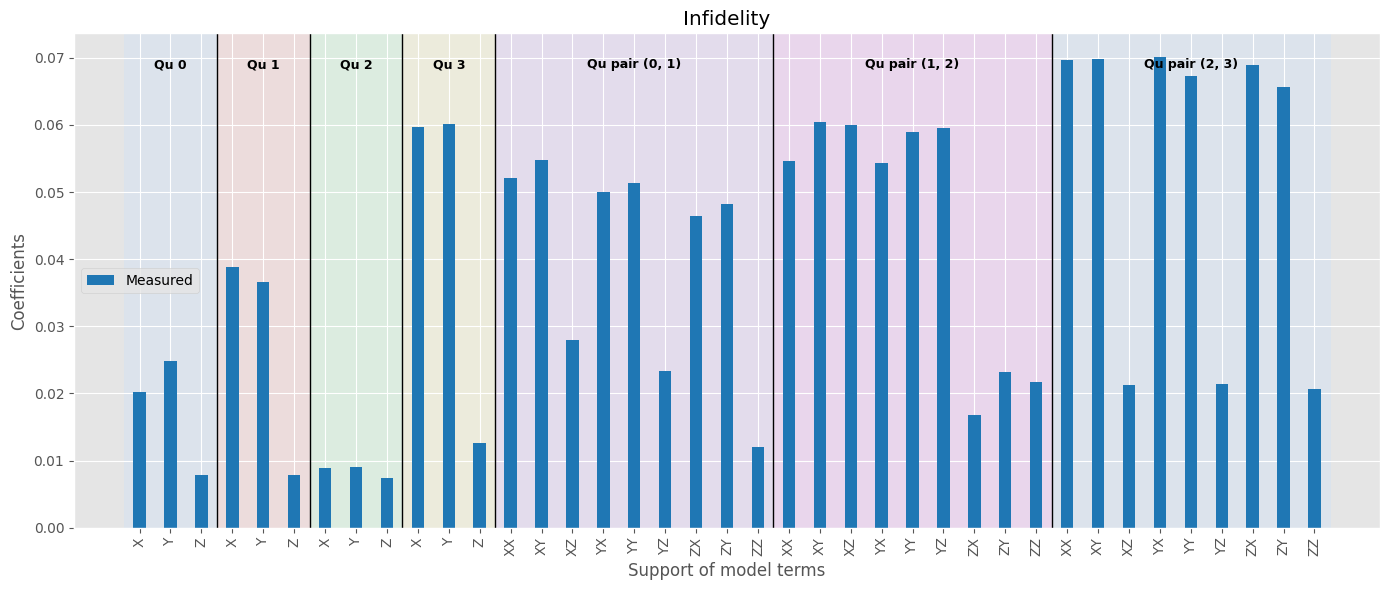

In [13]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

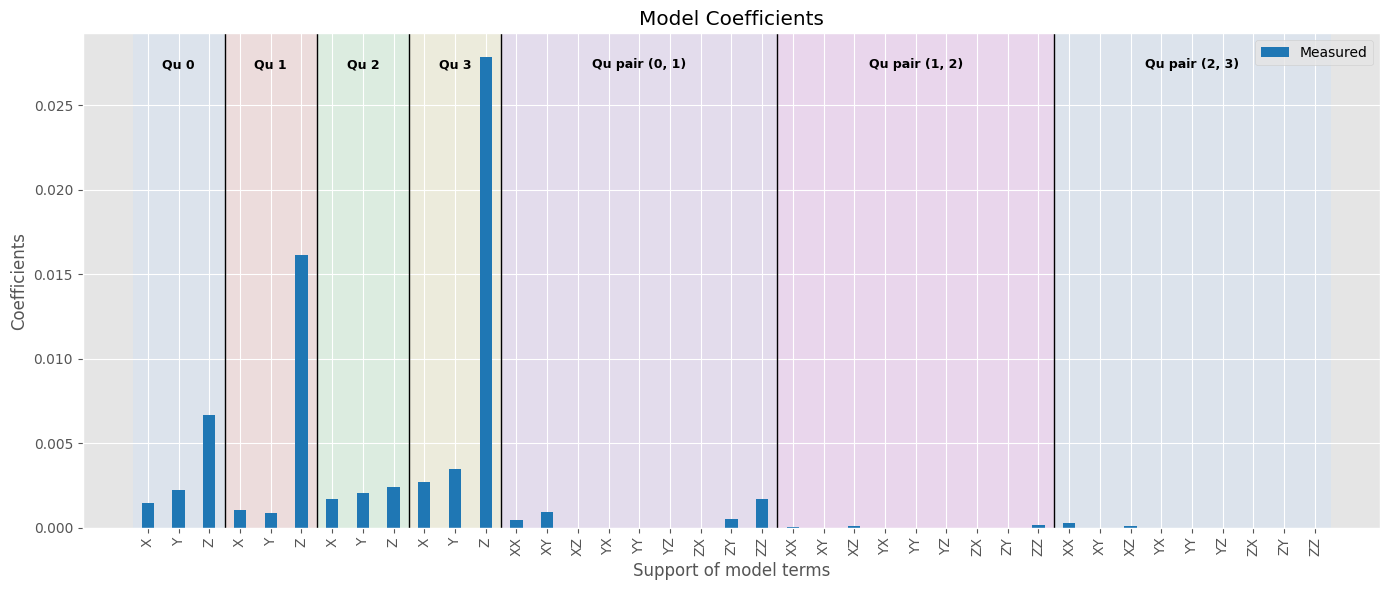

In [14]:
layer2.plot_coeffs(plot_style = 2)

In [15]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000, 
    noise_strengths=[0, 1, 2]
)
perexp.run(executor)

In [16]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

KeyboardInterrupt: 

In [ ]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()